# 📊 Detailed Exploratory Data Analysis (EDA)

In this notebook, we explore the synthetic e-commerce supply chain dataset to uncover patterns, anomalies, and the primary drivers of product returns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration for visualizations
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings("ignore")

## 1. Load Data

In [2]:
df = pd.read_csv("../data/final_combined_data.csv")
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())

Dataset Shape: 3000 rows x 51 columns


,order_id,customer_id,product_id,order_date,order_day_of_week,order_hour,quantity,product_price,discount_amount,discount_percentage,final_price,payment_method,is_cod,shipping_mode,courier_partner,warehouse_city,delivery_city,expected_delivery_days,actual_delivery_days,delivery_delay,distance_km,is_remote_area,delivery_attempts,courier_delay_rate,warehouse_processing_time,is_returned,return_reason,return_days_after_delivery,city,state,pincode,customer_tenure_days,total_orders,total_returns,overall_return_rate,avg_order_value,avg_days_between_orders,last_order_days_ago,preferred_category,frequent_return_flag,product_name,category,brand,price,price_band,product_return_rate,category_return_rate,avg_rating,rating_variance,size_variants_count,is_fragile
0,O1,C97,P4,2025-01-06,Monday,17,1,24990,2499.00,10,22491.00,COD,1,Express,Ecom Express,Hyderabad,Delhi,2,2,0,1377,1,3,0.29,1.28,0,NONE,0,Delhi,Delhi,196168,257,32,5,0.16,15282,27.115744,60,Apparel,0,Sony WH-1000XM4 Headphones,Electronics,Sony,24990,high,0.05,0.065,4.8,0.2,1,1
1,O2,C642,P6,2025-05-23,Friday,5,2,3199,767.76,12,5630.24,Card,0,Express,Delhivery,Bangalore,Hyderabad,1,3,2,1248,1,3,0.22,1.88,1,DAMAGED_IN_TRANSIT,3,Hyderabad,Telangana,719677,471,49,0,0.00,14765,19.180280,22,Electronics,0,Philips HL7756 Mixer Grinder,Home Appliances,Philips,3199,mid,0.07,0.070,4.2,0.5,1,1
2,O3,C475,P5,2025-04-21,Monday,12,1,3499,1399.60,40,2099.40,COD,1,Standard,Ecom Express,Chennai,Jaipur,4,7,3,910,1,2,0.16,1.01,1,WRONG_ITEM,7,Jaipur,Rajasthan,996531,705,13,0,0.00,4402,23.695355,29,Electronics,0,Levi's 511 Slim Jeans,Apparel,Levi's,3499,mid,0.22,0.235,3.9,0.9,6,0
3,O4,C842,P1,2025-04-14,Monday,10,1,11999,2279.81,19,9719.19,COD,1,Express,Delhivery,Mumbai,Delhi,1,1,0,414,0,1,0.29,1.19,0,NONE,0,Delhi,Delhi,466586,125,12,0,0.00,7175,26.704328,12,Electronics,0,Nike Air Zoom Pegasus 40,Footwear,Nike,11999,mid,0.12,0.120,4.5,0.4,8,0
4,O5,C947,P3,2025-12-07,Sunday,20,1,39999,3999.90,10,35999.10,UPI,0,Standard,Delhivery,Hyderabad,Mumbai,3,3,0,856,1,3,0.15,1.86,0,NONE,0,Mumbai,Maharashtra,810477,87,11,0,0.00,18825,6.305079,55,Home Appliances,0,Samsung Galaxy S21 FE,Electronics,Samsung,39999,high,0.08,0.065,4.3,0.3,1,1


## 2. Basic Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    3000 non-null   object 
 1   customer_id                 3000 non-null   object 
 2   product_id                  3000 non-null   object 
 3   order_date                  3000 non-null   object 
 4   order_day_of_week           3000 non-null   object 
 5   order_hour                  3000 non-null   int64  
 6   quantity                    3000 non-null   int64  
 7   product_price               3000 non-null   int64  
 8   discount_amount             3000 non-null   float64
 9   discount_percentage         3000 non-null   int64  
 10  final_price                 3000 non-null   float64
 11  payment_method              3000 non-null   object 
 12  is_cod                      3000 non-null   int64  
 13  shipping_mode               3000 

In [4]:
df.describe()

,order_hour,quantity,product_price,discount_amount,discount_percentage,final_price,is_cod,expected_delivery_days,actual_delivery_days,delivery_delay,distance_km,is_remote_area,delivery_attempts,courier_delay_rate,warehouse_processing_time,is_returned,return_days_after_delivery,pincode,customer_tenure_days,total_orders,total_returns,overall_return_rate,avg_order_value,avg_days_between_orders,last_order_days_ago,frequent_return_flag,price,product_return_rate,category_return_rate,avg_rating,rating_variance,size_variants_count,is_fragile
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,11.598000,1.207667,14360.001000,3021.929857,17.441000,14072.557477,0.417667,3.289000,4.074667,0.785667,996.276667,0.60000,1.995667,0.220250,1.978140,0.328333,1.779667,563645.967667,462.678333,27.551000,3.746667,0.131263,10672.093000,17.497593,32.000000,0.108000,14360.001000,0.130257,0.130662,4.290167,0.512800,3.642667,0.506333
std,6.989135,0.514421,13920.551064,4746.121845,12.878243,15951.337149,0.493257,1.763287,2.240855,1.247763,568.016340,0.48998,0.813553,0.088031,0.581239,0.469685,3.029441,257650.066291,248.839864,13.350786,4.249373,0.128657,5648.183001,7.276906,16.468852,0.310432,13920.551064,0.076203,0.075275,0.306656,0.255769,2.815248,0.500043
min,0.000000,1.000000,1799.000000,0.000000,0.000000,1043.420000,0.000000,0.000000,0.000000,0.000000,5.000000,0.00000,1.000000,0.050000,1.000000,0.000000,0.000000,102973.000000,30.000000,5.000000,0.000000,0.000000,522.000000,5.013573,1.000000,0.000000,1799.000000,0.050000,0.065000,3.900000,0.200000,1.000000,0.000000
25%,5.000000,1.000000,3199.000000,247.420000,9.000000,2559.200000,0.000000,2.000000,2.000000,0.000000,513.750000,0.00000,1.000000,0.160000,1.470000,0.000000,0.000000,349185.000000,242.000000,16.000000,0.000000,0.000000,5485.000000,11.130783,19.000000,0.000000,3199.000000,0.070000,0.065000,4.000000,0.300000,1.000000,0.000000
50%,12.000000,1.000000,11999.000000,979.720000,20.000000,8279.310000,0.000000,3.000000,4.000000,0.000000,984.000000,1.00000,2.000000,0.220000,1.960000,0.000000,0.000000,566297.000000,460.000000,28.000000,2.000000,0.110000,11100.000000,17.256721,32.500000,0.000000,11999.000000,0.080000,0.070000,4.300000,0.400000,1.000000,1.000000
75%,18.000000,1.000000,24990.000000,3999.900000,30.000000,22491.000000,1.000000,5.000000,6.000000,1.000000,1484.250000,1.00000,3.000000,0.280000,2.480000,1.000000,3.000000,796482.000000,674.000000,39.000000,6.000000,0.200000,15593.000000,23.933763,46.000000,0.000000,24990.000000,0.220000,0.235000,4.500000,0.800000,6.000000,1.000000
max,23.000000,3.000000,39999.000000,50398.740000,42.000000,119997.000000,1.000000,6.000000,13.000000,7.000000,2000.000000,1.00000,3.000000,0.400000,3.000000,1.000000,10.000000,999908.000000,899.000000,50.000000,25.000000,0.710000,19977.000000,29.981047,60.000000,1.000000,39999.000000,0.250000,0.235000,4.800000,0.900000,8.000000,1.000000


## 3. Target Variable (Return Rate) Distribution

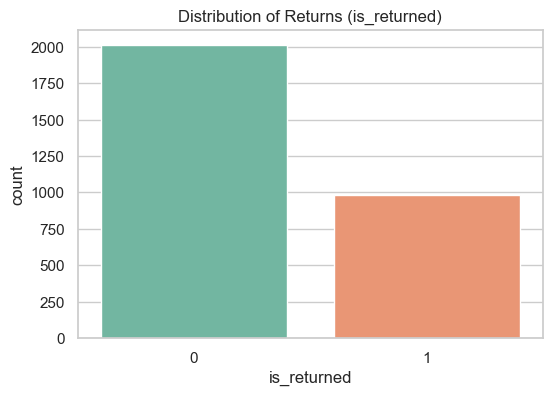

Overall Global Return Rate: 32.83%


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_returned", palette="Set2")
plt.title("Distribution of Returns (is_returned)")
plt.show()

return_rate = df["is_returned"].mean() * 100
print(f"Overall Global Return Rate: {return_rate:.2f}%")

## 4. Key Drivers of Returns (Bivariate Analysis)

### A. Delivery Delay vs. Returns

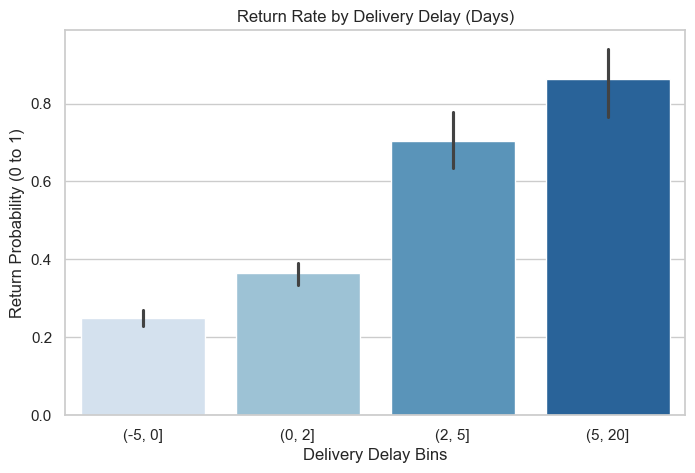

In [6]:
plt.figure(figsize=(8, 5))
df["delay_bins"] = pd.cut(df["delivery_delay"], bins=[-5, 0, 2, 5, 20])
sns.barplot(data=df, x="delay_bins", y="is_returned", palette="Blues")
plt.title("Return Rate by Delivery Delay (Days)")
plt.ylabel("Return Probability (0 to 1)")
plt.xlabel("Delivery Delay Bins")
plt.show()

### B. Discounts vs. Returns

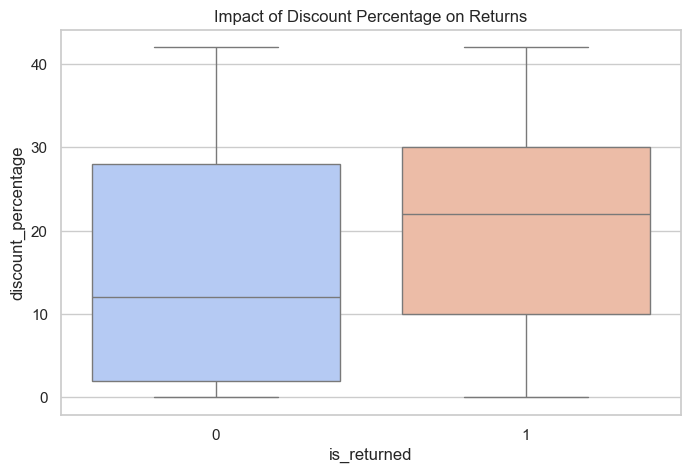

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_returned", y="discount_percentage", palette="coolwarm")
plt.title("Impact of Discount Percentage on Returns")
plt.show()

### C. Product Rating vs. Returns

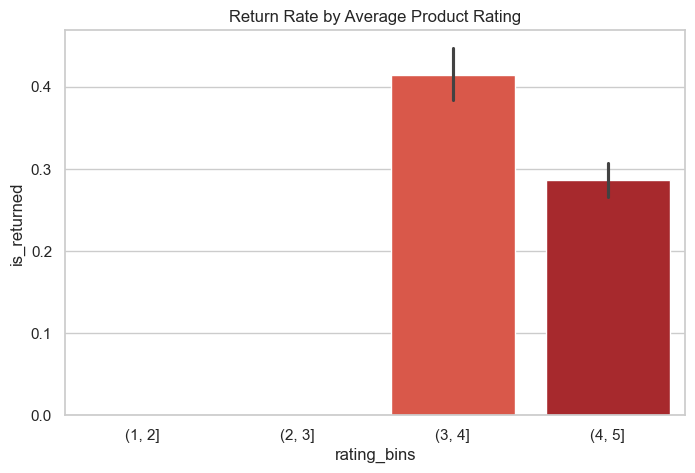

In [8]:
plt.figure(figsize=(8, 5))
df["rating_bins"] = pd.cut(df["avg_rating"], bins=[1, 2, 3, 4, 5])
sns.barplot(data=df, x="rating_bins", y="is_returned", palette="Reds")
plt.title("Return Rate by Average Product Rating")
plt.show()

## 5. Temporal Patterns

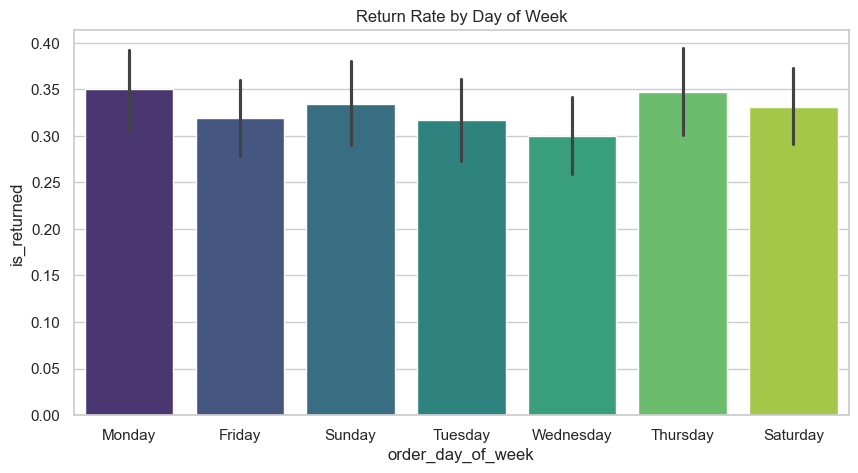

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="order_day_of_week", y="is_returned", palette="viridis")
plt.title("Return Rate by Day of Week")
plt.show()

## 6. Correlation Matrix

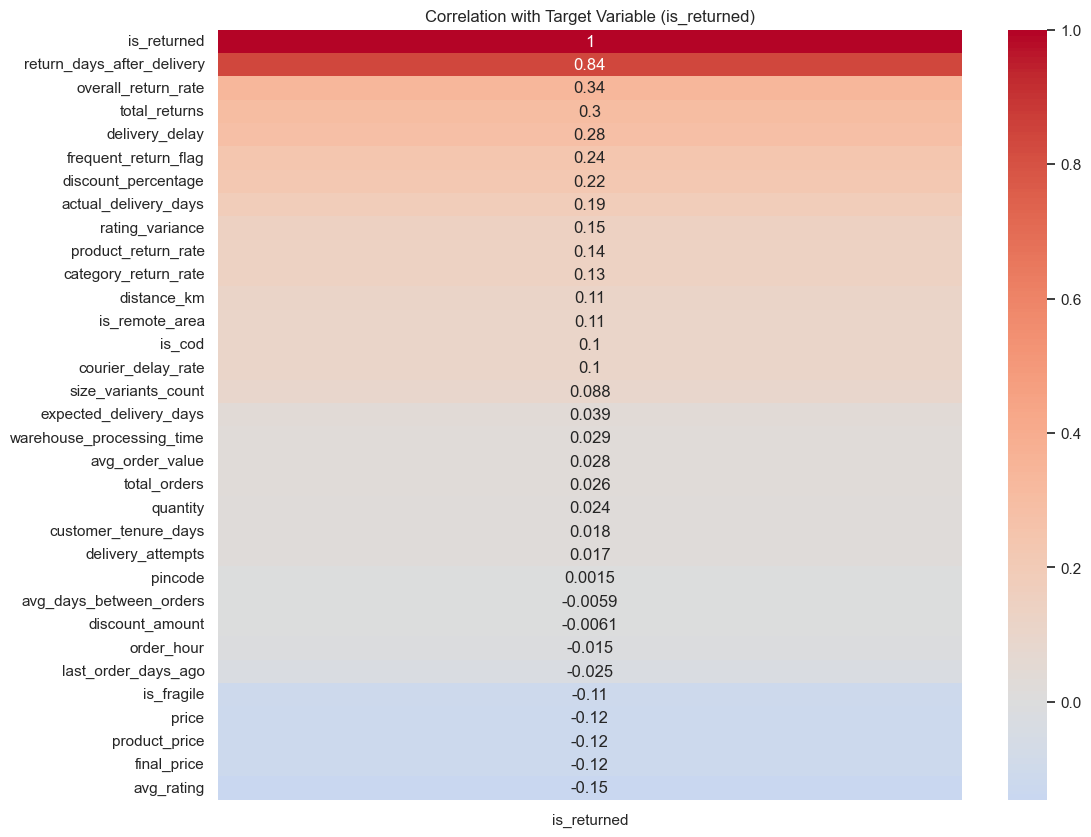

In [10]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[["is_returned"]].sort_values(by="is_returned", ascending=False), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation with Target Variable (is_returned)")
plt.show()

## 7. Conclusions

- **Delivery Delays** predictably skyrocket the return probability.
- **Deep Discounts** correlate closely with higher returns, often indicating impulse buying.
- **Poor Product Ratings** strongly dictate future return behaviors.
- The dataset possesses strong, learnable multi-domain (Logistics + Customer + Product) variances making it highly valuable for real-world ML modeling.